<a href="https://colab.research.google.com/github/emilchafigoulline/Data-Science/blob/main/Unit3/EmilChafU3Proj.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction
In this project, I will be modeling the increase in the S&P 500 stock index on a given month. The S&P 500 is an index composed of the market values of the top 500 companies listed for trading in the U.S. trade market. It's generally an accurate reflection of the general strength of the market. As such, I'm interested in using data to predict the future growth of the index.

In [ ]:
import pymc as pm #importing neccessary libraries
import numpy as np
import pandas as pd
!pip install preliz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.6/519.6 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.8/108.8 kB 7.3 MB/s eta 0:00:00


In [ ]:
import preliz as pz
import arviz as az
import matplotlib.pyplot as plt

# Data
For the data, I used a website that provided the last 500 months of the closing price of the S&P 500 stock index, and I then used excel to find the change between the first and last days of the month. This data will allow me to find an accurate representation of the index over time. To gain a sense of the approximate distribution of the data, I will plot it using a histogram with 50 buckets, allowing for a fairly detailed spread of the data. By using a large sample size, my model will give predictions for the movements of the stock index over a long period of time, allowing for greater accurary for the long-term, which is what is most worthwhile when investing in index funds such as the S&P 500. I then found the mean, median, and mode, which indicated that the distribution is skewed to the left, with the median being greater than the mean.

In [ ]:
url_stockdata = ("https://raw.githubusercontent.com/emilchafigoulline/Data-Science/refs/heads/main/S%26P%20Return%20Positive_Negative%20-%20Sheet1-1%20-%20Sheet1.csv")
stockdata = pd.read_csv(url_stockdata)[['Change']]
stockdatatrimmed = stockdata['Change'].iloc[:-1]
stockdatazoom = (stockdatatrimmed.astype(float))*100
stockdatazoom


,Change
0,-0.692232
1,1.906650
2,2.166657
3,4.960680
4,6.152385
...,...
494,-1.645123
495,1.746928
496,-5.935645
497,0.546551


(array([ 1.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  1.,  0.,  0.,
         1.,  0.,  2.,  0.,  3.,  7.,  6.,  3.,  5., 10.,  7.,  8.,  8.,
        15., 20., 35., 18., 25., 34., 47., 43., 35., 27., 37., 19., 22.,
        17.,  8., 12.,  6.,  6.,  4.,  0.,  3.,  1.,  0.,  2.]),
 array([-21.7630426 , -21.06424787, -20.36545313, -19.6666584 ,
        -18.96786367, -18.26906893, -17.5702742 , -16.87147947,
        -16.17268473, -15.47389   , -14.77509527, -14.07630053,
        -13.3775058 , -12.67871107, -11.97991634, -11.2811216 ,
        -10.58232687,  -9.88353214,  -9.1847374 ,  -8.48594267,
         -7.78714794,  -7.0883532 ,  -6.38955847,  -5.69076374,
         -4.991969  ,  -4.29317427,  -3.59437954,  -2.8955848 ,
         -2.19679007,  -1.49799534,  -0.7992006 ,  -0.10040587,
          0.59838886,   1.2971836 ,   1.99597833,   2.69477306,
          3.3935678 ,   4.09236253,   4.79115726,   5.48995199,
          6.18874673,   6.88754146,   7.58633619,   8.28513093,
          8.

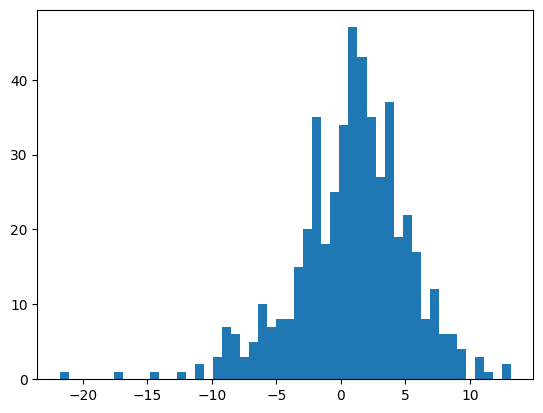

In [ ]:
plt.hist(stockdatazoom,50)
#divides data into 50 buckets

In [ ]:
mean = stockdatazoom.mean()
median = stockdatazoom.median()

print("Mean: ",mean)
print("Median: ",median)
#used to display the median and mean of the dataset; shows the skew

Mean:  0.8427755736407194
Median:  1.215566041


# Prior Models
For the S&P 500 model, I will use a StudentT distribution to describe it. This is because the StudentT distribution allows for fairly normal data, but has a greater kurtosis that I expect to see from a stock index such as the S&P 500. As such, I will need a prior for three distribtuions: the mean, mu, the standard deviation, sigma, and the normality, nu. For the mean, I will use a normal distribution, as high values of increase/decrease will be increasingly more rare, and most months the index will stay in a similar range. I will use a mean of 0.67, as the S&P 500 produces around an 8% yearly return to the best of my knowledge. However, since I am not confident in this value, I will use a fairly large standard deviation with value 20. This is an arbitrary value that is large enough to make sure I don't influence the distribtuion with a bad prior.


<Axes: >

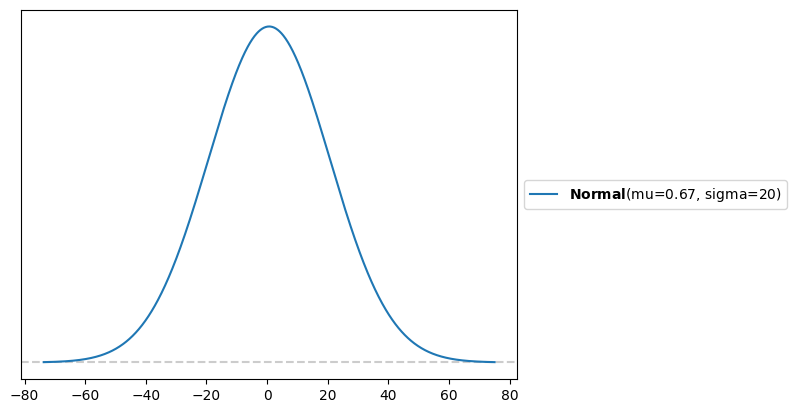

In [ ]:
stockMean = pz.Normal(mu = 0.67, sigma = 20)
stockMean.plot_pdf()
#Mean prior

Next, I will need to describe the standard deviation of the stock index, sigma. However, I don't have enough knowledge on this in order to create a descriptive prior. Therefore, I will use a uniform distribtuion to represent the standard deviation of the index. I will use a uniform distribution from values -20 to 20, allowing for possible high amounts of variation between values and keeping my prior relatively uninformative.

<Axes: >

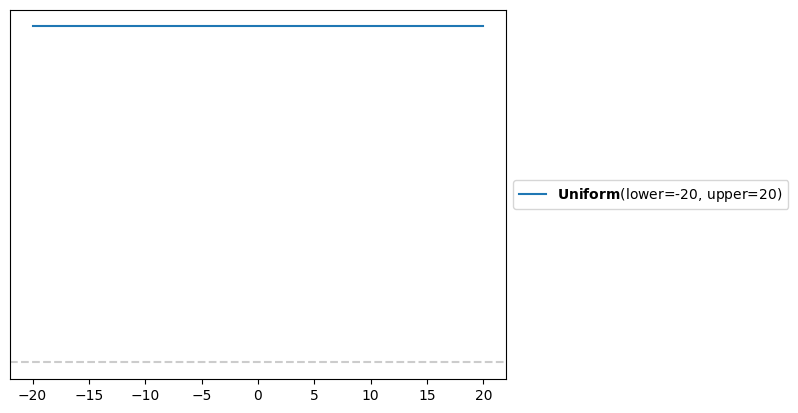

In [ ]:
stockSD = pz.Uniform(lower = -20, upper = 20)
stockSD.plot_pdf()
#Standard deviation prior

The final distribution that I need to get for my prior is the normality. While I am not completely sure about the value, and so am not able to create an informative prior, I know that the normality value will be fairly high, since I'm anticipating that the stock index will follow a StudentT distrubtion with a fairly normal distribtuion. As such, I'll choose a uniform distrubtion with normality betwee 15 and 25, giving me a high but not completely normal normality value.

<Axes: >

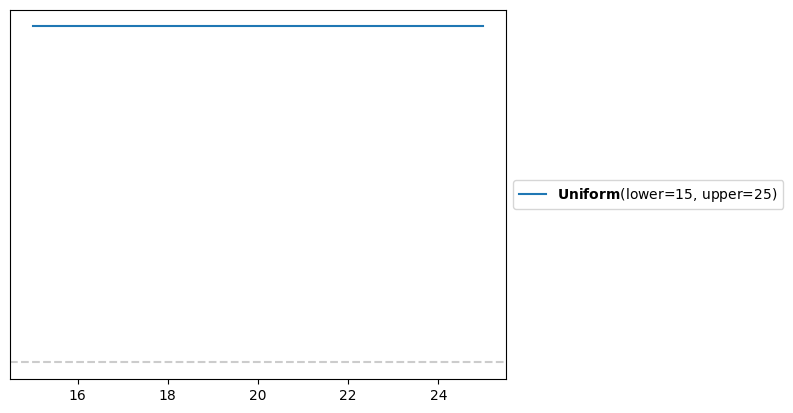

In [ ]:
stockNormality = pz.Uniform(lower= 15, upper = 25)
stockNormality.plot_pdf()
#Normality prior

# Model Construction
Now that my priors and data have both been defined, I'm able to construct my initial model. My mean will represent mu, my standard deviation prior will represent sigma, my normality prior will respresent nu, and I will use my data as my observed. I will represent the model using a StudentT distibution, as I feel that this will be the most accurate to the stock index.

In [ ]:
with pm.Model() as stock_data_model:
  #mean prior
  mu = pm.Normal('mu', mu = 0.67, sigma = 20)

  #standard deviation prior
  sigma = pm.Uniform('sigma', lower = -20, upper = 20)

  #normality prior
  nu = pm.Uniform('nu', lower = 15, upper = 25)

  #observed data
  y = pm.StudentT('y', mu = mu, sigma = sigma, nu = nu, observed = stockdatazoom)

  idata_stock_model = pm.sample()

Output()

In [ ]:
pm.sample_posterior_predictive(idata_stock_model, model = stock_data_model, extend_inferencedata=True)

(-20.0, 20.0)

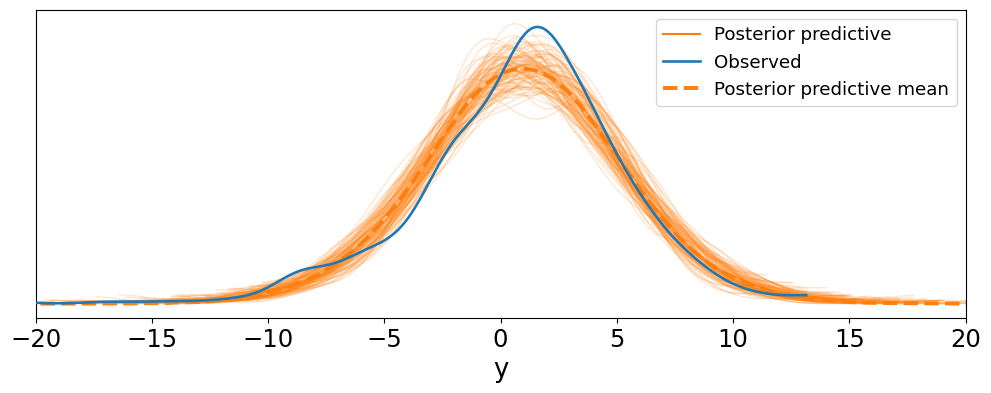

In [ ]:
ax = az.plot_ppc(idata_stock_model, num_pp_samples=100, figsize=(12, 4), colors=["C1", "C0", "C1"], )
ax.set_xlim(-20, 20)

Now, after modeling, we can see that our distrubtion matches up decently well with the observed data! However, the model is slightly skewed to the left, as is typical of stocks such as this one. As such, I'll use a skewed Student T distrubtion to try and guess with parameters a and b to find a model that is more accurate(suggested by Yale). Since I don't have actual parameters for a and b, I'll need to run the model multiple times to find one that fits.

In [ ]:
with pm.Model() as stock_data_skewed_model:
  #mean prior
  mu = pm.Normal('mu', mu = 0.67, sigma = 20)

  #standard deviation prior
  sigma = pm.Uniform('sigma', lower = -20, upper = 20)

  y = pm.SkewStudentT('y', mu = mu, sigma = sigma, a = 2, b = 5, observed = stockdatazoom)
  idata_stock_skewed_model = pm.sample()

In [ ]:
pm.sample_posterior_predictive(idata_stock_skewed_model, model = stock_data_skewed_model, extend_inferencedata=True)

(-15.0, 15.0)

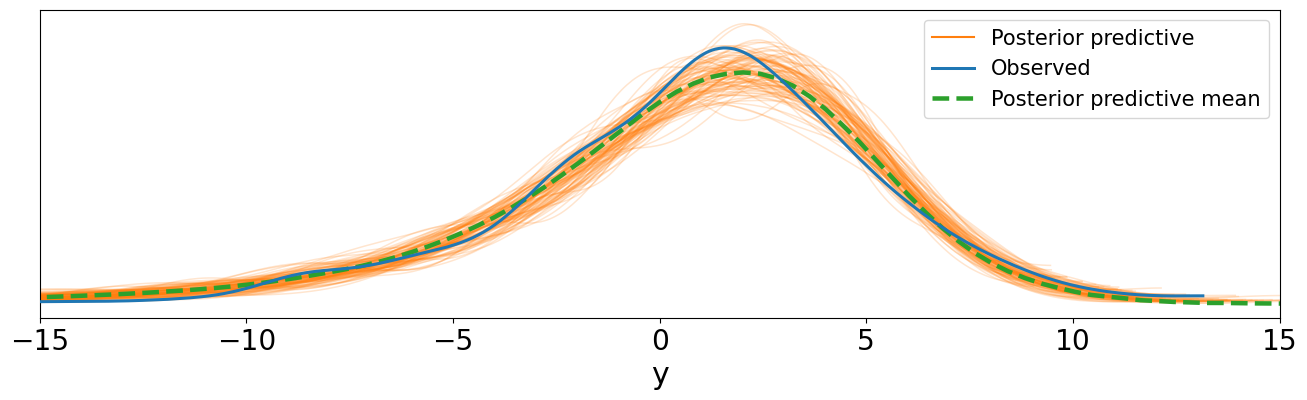

In [26]:
ax = az.plot_ppc(idata_stock_skewed_model, num_pp_samples=100, figsize=(16, 4), colors=["C1", "C0", "C2"])
ax.set_xlim(-15, 15)

And now, by using a skew student T distribution, we have a model that is close enough to our observed data that we are able to use it to predict things about the real world. The S&P 500 stock index is slightly left skewed, increasing with a mean of about 2.5% per month. However, there is variation such that the distribution fits a StudentT model, allowing us to predict the outcome of the stock index in real life, despite it not completely matching the real world.